### Random Imputer

In [1]:
df = pd.read_csv(r"\Users\Anjli Kumari\datasets\titanic.csv",usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [2]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [3]:
X = df.drop(columns=['Survived'])
Y = df['Survived']

In [4]:
X_train,X_test,Y_train,Y_test = train(X,Y,0.2,2)

In [5]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [6]:
X_train.head()

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0


In [7]:
train_missing = X_train['Age_imputed'].isnull()
X_train.loc[train_missing, 'Age_imputed'] = (X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values)
test_missing = X_test['Age_imputed'].isnull()
X_test.loc[test_missing, 'Age_imputed'] = (X_test['Age'].dropna().sample(X_test['Age'].isnull().sum()).values)

In [8]:
X_train[['Age_imputed','Age']].sample(25)

,Age_imputed,Age
105,28.0,28.0
155,51.0,51.0
232,59.0,59.0
625,61.0,61.0
466,19.0,NaN
577,39.0,39.0
832,18.0,NaN
329,16.0,16.0
646,19.0,19.0
350,23.0,23.0


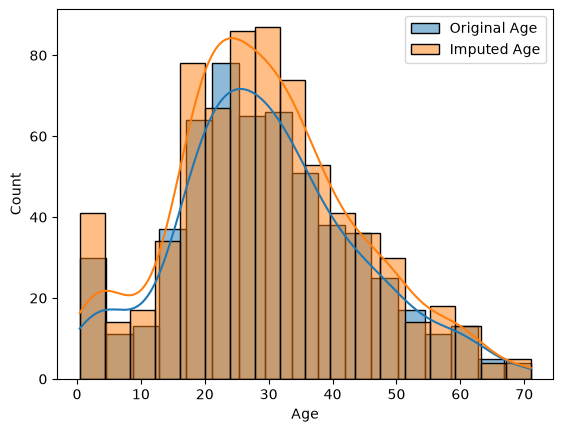

In [9]:
sns.histplot(data=X_train,x='Age',label='Original Age',kde=True)
sns.histplot(data=X_train,x='Age_imputed',label='Imputed Age',kde=True)
plt.legend()
plt.show()

In [10]:
print('Original Data Age Variance:',X_train['Age'].var())
print('Imputed Data Age Variance:',X_train['Age_imputed'].var())

Original Data Age Variance: 204.34951339046142
Imputed Data Age Variance: 205.9609146365698


In [11]:
X_train[['Fare','Age','Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,53.714469
Age,71.512440,204.349513,204.349513
Age_imputed,53.714469,204.349513,205.960915


<Axes: >

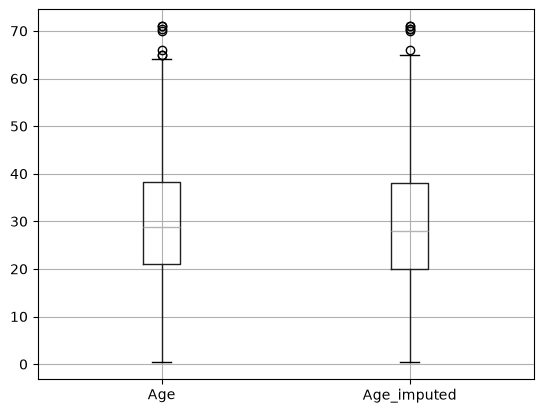

In [12]:
X_train[['Age','Age_imputed']].boxplot()

In [13]:
observation = X_train.iloc[0]
sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))

### Missing Value Imputer

#### Method 1 (Pandas)

In [1]:
data = pd.read_csv(r"\Users\Anjli Kumari\datasets\advance_regression_housing.csv",usecols=['GarageQual','FireplaceQu','SalePrice'])
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [2]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [3]:
X = data
Y = data['SalePrice']

In [4]:
X_train,X_test,Y_train,Y_test = train(X,Y,0.2,2)

In [5]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [6]:
X_test.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
1404,NaN,TA,105000,TA,NaN
239,Gd,TA,113000,TA,Gd
839,NaN,TA,130500,TA,NaN
956,TA,TA,124000,TA,TA
608,Gd,TA,359100,TA,Gd


In [7]:
Train_GarageQual_missing = X_train['GarageQual_imputed'].isnull()
X_train.loc[Train_GarageQual_missing, 'GarageQual_imputed'] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
Test_GarageQual_missing = X_test['GarageQual_imputed'].isnull()
X_test.loc[Test_GarageQual_missing, 'GarageQual_imputed'] = X_test['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values
Train_FireplaceQu_missing = X_train['FireplaceQu_imputed'].isnull()
X_train.loc[Train_FireplaceQu_missing, 'FireplaceQu_imputed'] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
Test_FireplaceQu_missing = X_test['FireplaceQu_imputed'].isnull()
X_test.loc[Test_FireplaceQu_missing, 'FireplaceQu_imputed'] = X_test['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

In [16]:
temp = pd.concat(
    [
        X_train['GarageQual'].value_counts()/len(X_train['GarageQual'].dropna()),
        X_train['GarageQual_imputed'].value_counts()/len(X_train)
    ],axis=1)
temp.columns = ['Original','Imputed']
temp.head()        

,Original,Imputed
TA,0.951043,0.953767
Fa,0.037171,0.035103
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [12]:
temp = pd.concat(
    [
        X_train['FireplaceQu'].value_counts()/len(X_train['FireplaceQu'].dropna()),
        X_train['FireplaceQu_imputed'].value_counts()/len(data)
    ],axis=1)
temp.columns = ['Original','Imputed']
temp.head()        

,Original,Imputed
Gd,0.494272,0.394521
TA,0.412439,0.330822
Fa,0.040917,0.032192
Po,0.027823,0.022603
Ex,0.024550,0.019863


C:\Users\Anjli Kumari\AppData\Local\Temp\ipykernel_26440\674568557.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
C:\Users\Anjli Kumari\AppData\Local\Temp\ipykernel_26440\674568557.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de441

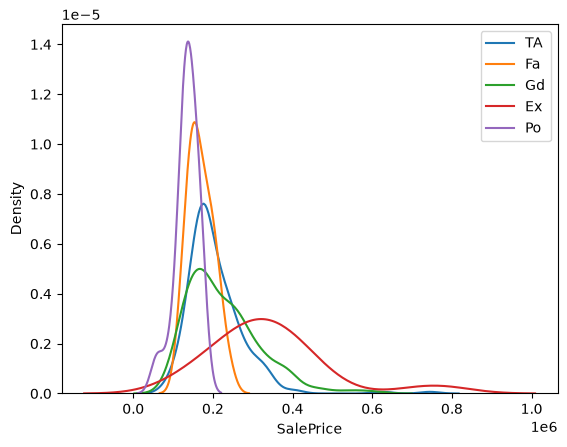

In [20]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
plt.legend()
plt.show()

C:\Users\Anjli Kumari\AppData\Local\Temp\ipykernel_26440\4216822332.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
C:\Users\Anjli Kumari\AppData\Local\Temp\ipykernel_26440\4216822332.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwa

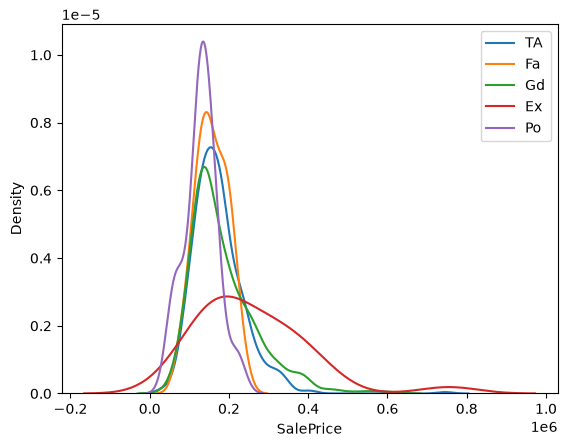

In [21]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
plt.legend()
plt.show()

In [1]:
df = pd.read_csv(r"\Users\Anjli Kumari\datasets\titanic.csv",usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [2]:
X = df.drop(columns=['Survived'])
Y = df['Survived']

In [23]:
X_train,X_test,Y_train,Y_test = train(X,Y,0.2,2)

In [4]:
X_train.head()

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458


In [5]:
si = imputer()
X_train_trf = si.fit_transform(X_train)
X_test_trf = si.transform(X_test)

In [6]:
X_train_trf

array([[ 40.        ,  27.7208    ],
       [  4.        ,  16.7       ],
       [ 47.        ,   9.        ],
       ...,
       [ 71.        ,  49.5042    ],
       [ 29.78590426, 221.7792    ],
       [ 29.78590426,  25.925     ]], shape=(712, 2))

In [7]:
lr = LogisticRegression()
lr.fit(X_train_trf,Y_train)
Y_pred = lr.predict(X_test_trf)
accuracy_score(Y_test,Y_pred)

0.6145251396648045

In [8]:
from sklearn.impute import MissingIndicator
mi = MissingIndicator()

In [9]:
mi.fit(X_train)

MissingIndicator()

In [10]:
mi.features_

array([0])

In [11]:
X_train_missing = mi.transform(X_train)

In [12]:
X_train_missing

array([[False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [

In [13]:
X_test_missing = mi.transform(X_test)

In [14]:
X_test_missing

array([[False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [

In [15]:
X_train['Age_NA'] = X_train_missing
X_test['Age_NA'] = X_test_missing

In [16]:
X_train

,Age,Fare,Age_NA
30,40.0,27.7208,False
10,4.0,16.7000,False
873,47.0,9.0000,False
182,9.0,31.3875,False
876,20.0,9.8458,False
...,...,...,...
534,30.0,8.6625,False
584,NaN,8.7125,True
493,71.0,49.5042,False
527,NaN,221.7792,True


In [17]:
X_test.sample(4)

,Age,Fare,Age_NA
816,23.0,7.925,False
179,36.0,0.000,False
426,28.0,26.000,False
712,48.0,52.000,False


In [18]:
si = imputer()
X_train_trf2 = si.fit_transform(X_train)
X_test_trf2 = si.transform(X_test)

In [19]:
lr = LogisticRegression()
lr.fit(X_train_trf2,Y_train)
Y_pred = lr.predict(X_test_trf2)
accuracy_score(Y_test,Y_pred)

0.6312849162011173

#### Method 2 (Scikit-Learn)

In [20]:
si = SimpleImputer(add_indicator=True)

In [24]:
X_train = si.fit_transform(X_train)

In [25]:
X_test = si.transform(X_test)

In [26]:
lr = LogisticRegression()
lr.fit(X_train_trf2,Y_train)
Y_pred = lr.predict(X_test_trf2)
accuracy_score(Y_test,Y_pred)

0.6312849162011173

### Selection Of Best Imputer Using GridSearchCV

In [1]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder

In [3]:
df = pd.read_csv(r"\Users\Anjli Kumari\datasets\titanic.csv")
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.drop(columns=['PassengerId','Name','Ticket','Cabin'],inplace=True)
df.head(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [5]:
X = df.drop(columns=['Survived'])
Y = df['Survived']

In [6]:
X_train,X_test,Y_train,Y_test = train(X,Y,0.2,2)

In [7]:
X_train.head(5)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
30,1,male,40.0,0,0,27.7208,C
10,3,female,4.0,1,1,16.7000,S
873,3,male,47.0,0,0,9.0000,S
182,3,male,9.0,4,2,31.3875,S
876,3,male,20.0,0,0,9.8458,S


In [8]:
numerical_features = ['Age','Fare']
numerical_transformer = Pipeline(steps=[
    ('imputer',imputer('median')),
    ('scaler',StandardScaler())
])
categorical_features = ['Embarked','Sex']
categorical_transformer = Pipeline(steps=[
    ('imputer',imputer('most_frequent')),
    ('ohe',OneHotEncoder(handle_unknown='ignore'))
])

In [9]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num',numerical_transformer,numerical_features),
        ('cat',categorical_transformer,categorical_features)
    ]
)

In [11]:
final_pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('classifier',LogisticRegression())
])

In [12]:
from sklearn import set_config
set_config(display='diagram')
final_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [20]:
param_grid = {
    'preprocessor__num__imputer__strategy' : ['mean','median'],
    'preprocessor__cat__imputer__strategy' : ['most_frequent','constant'],
    'classifier__C':[0.1,1.0,10,100]
}

grid_search = GridSearchCV(final_pipeline,param_grid,cv=10)

In [21]:
grid_search.fit(X_train,Y_train)
print(f"Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'classifier__C': 1.0, 'preprocessor__cat__imputer__strategy': 'most_frequent', 'preprocessor__num__imputer__strategy': 'mean'}


In [23]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results = cv_results.sort_values("mean_test_score",ascending=False)
cv_results[['param_classifier__C','param_preprocessor__cat__imputer__strategy','param_preprocessor__num__imputer__strategy','mean_test_score']]

,param_classifier__C,param_preprocessor__cat__imputer__strategy,param_preprocessor__num__imputer__strategy,mean_test_score
7,1.0,constant,median,0.787852
6,1.0,constant,mean,0.787852
5,1.0,most_frequent,median,0.787852
4,1.0,most_frequent,mean,0.787852
11,10.0,constant,median,0.787852
10,10.0,constant,mean,0.787852
9,10.0,most_frequent,median,0.787852
8,10.0,most_frequent,mean,0.787852
12,100.0,most_frequent,mean,0.787852
13,100.0,most_frequent,median,0.787852
